In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor


In [2]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


print(" 데이터 shape:", train.shape)


 데이터 shape: (10886, 12)


In [3]:
print("\n 데이터 상위 5행")
print(train.head())
print("\n 테스트데이터 상위 5행")
print(test.head())



 데이터 상위 5행
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

 테스트데이터 상위 5행
              datetime  season  holiday  workingday  weather   temp   atemp  \
0  2011-01-20 00:00:00       1        0           1        1  10.66  11.365   
1  2011-01-20 01:00:00       1    

In [4]:
print("\n 데이터 기본 정보")
print(train.info())
print("\n 테스트데이터 기본 정보")
print(test.info())



 데이터 기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None

 테스트데이터 기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null  

In [5]:

missing = train.isnull().sum()

missing_df = pd.DataFrame({'결측치 수': missing})
print(missing_df)

            결측치 수
datetime        0
season          0
holiday         0
workingday      0
weather         0
temp            0
atemp           0
humidity        0
windspeed       0
casual          0
registered      0
count           0


In [6]:
# 2. 데이터 클렌징 및 가공

# datetime 분리
train['datetime'] = pd.to_datetime(train['datetime'])
train['year']     = train['datetime'].apply(lambda x: x.year)
train['month']    = train['datetime'].apply(lambda x: x.month)
train['day']      = train['datetime'].apply(lambda x: x.day)
train['hour']     = train['datetime'].apply(lambda x: x.hour)
train['weekday']  = train['datetime'].apply(lambda x: x.weekday())




train.drop(['datetime', 'casual', 'registered'], axis=1, inplace=True)


print("Train columns:", train.columns.tolist())


Train columns: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'hour', 'weekday']


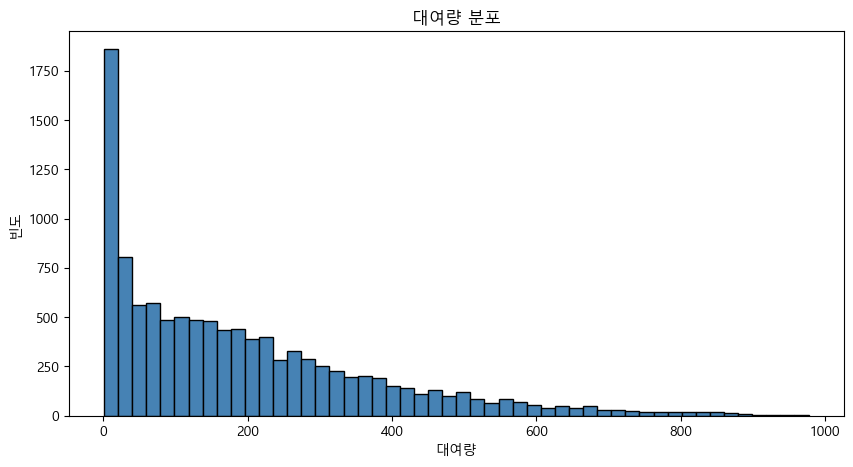

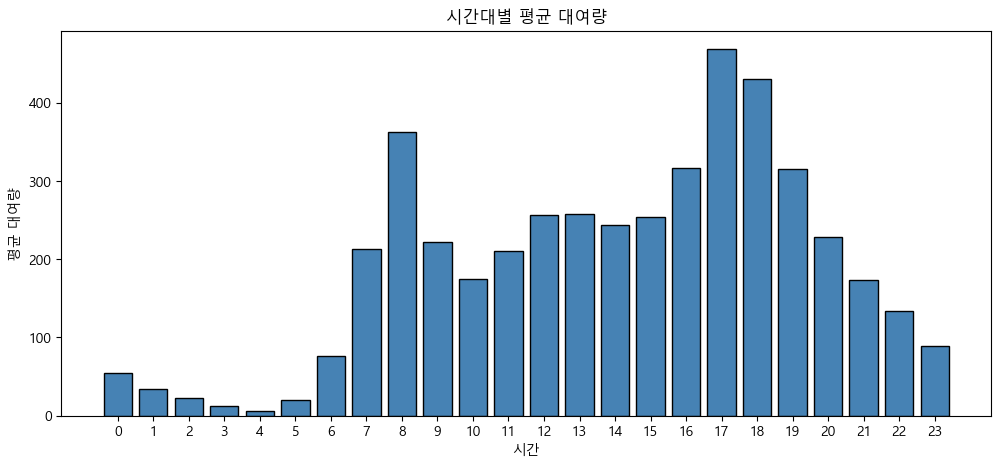

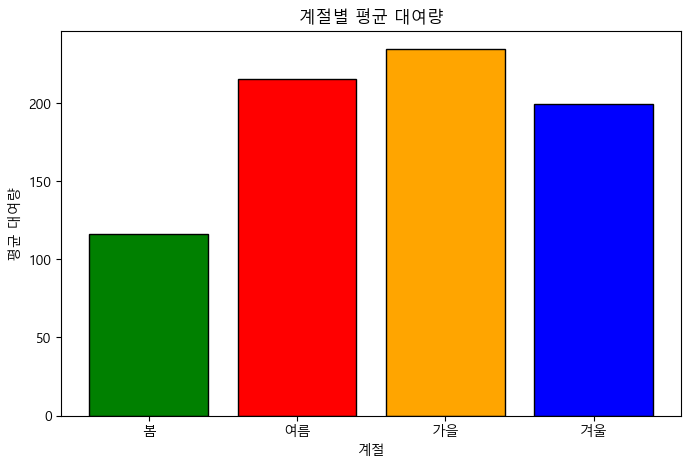

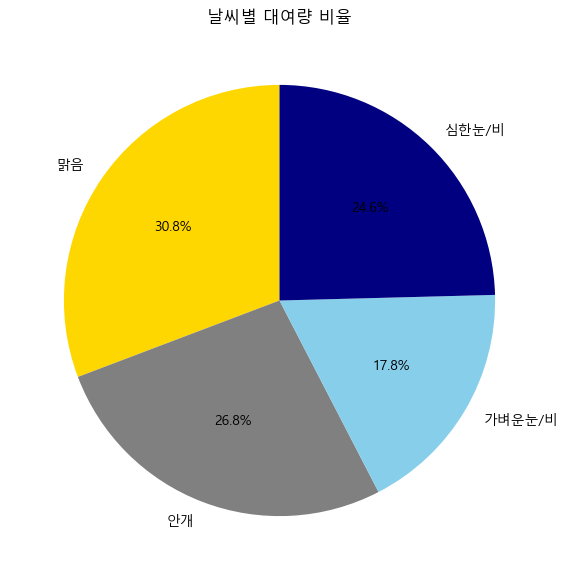

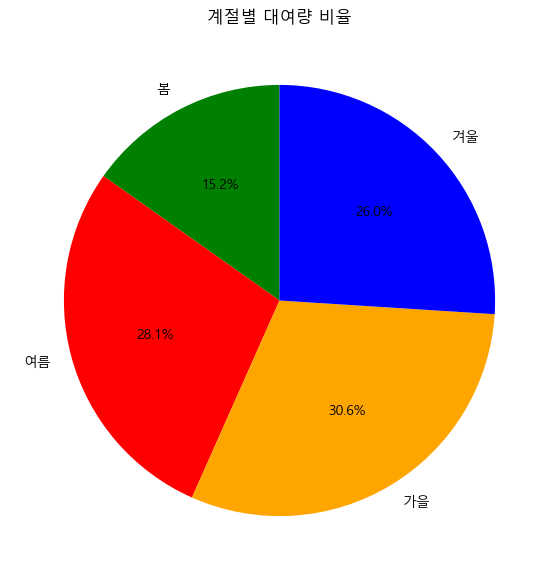

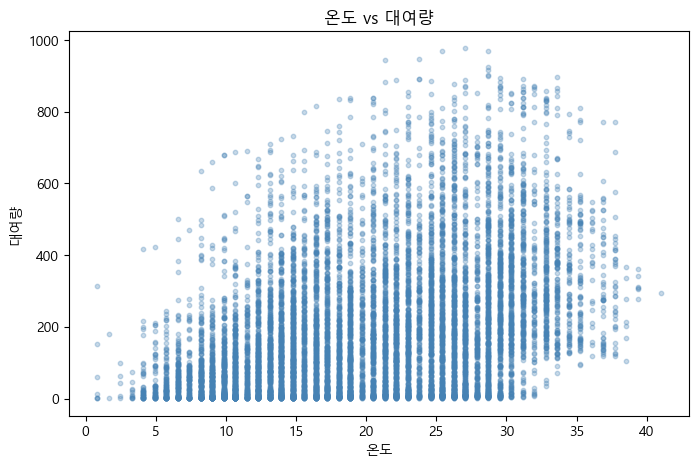

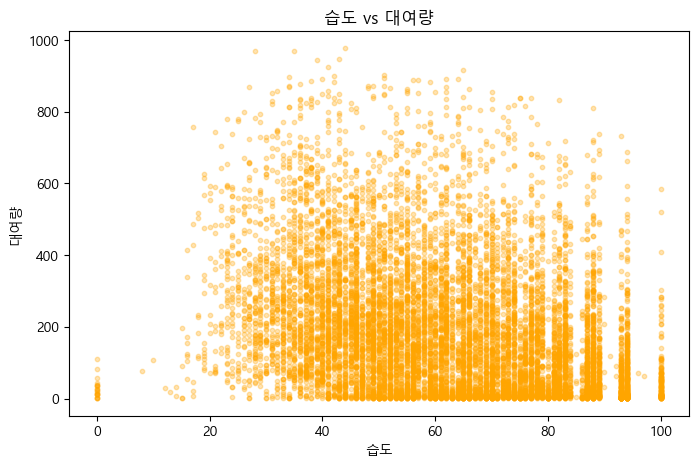

In [7]:

plt.rcParams['font.family'] = 'Malgun Gothic'   
plt.rcParams['axes.unicode_minus'] = False




#  count 분포 막대그래프 
plt.figure(figsize=(10, 5))
plt.hist(train['count'], bins=50, color='steelblue', edgecolor='black')
plt.title('대여량 분포')
plt.xlabel('대여량')
plt.ylabel('빈도')
plt.show()

#  시간대별 평균 대여량 막대그래프 
hour_mean = train.groupby('hour')['count'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hour_mean.index, hour_mean.values, color='steelblue', edgecolor='black')
plt.title('시간대별 평균 대여량')
plt.xlabel('시간')
plt.ylabel('평균 대여량')
plt.xticks(range(0, 24))
plt.show()

#  계절별 평균 대여량 막대그래프 
season_labels = ['봄', '여름', '가을', '겨울']
season_mean = train.groupby('season')['count'].mean()

plt.figure(figsize=(8, 5))
plt.bar(season_labels, season_mean.values, color=['green', 'red', 'orange', 'blue'], edgecolor='black')
plt.title('계절별 평균 대여량')
plt.xlabel('계절')
plt.ylabel('평균 대여량')
plt.show()

#  날씨별 대여량 원형그래프 
weather_labels = ['맑음', '안개', '가벼운눈/비', '심한눈/비']
weather_mean = train.groupby('weather')['count'].mean()

plt.figure(figsize=(7, 7))
plt.pie(weather_mean.values,
        labels=weather_labels,
        autopct='%1.1f%%',          
        colors=['gold', 'gray', 'skyblue', 'navy'],
        startangle=90)              
plt.title('날씨별 대여량 비율')
plt.show()

#  계절별 대여량 원형그래프 
plt.figure(figsize=(7, 7))
plt.pie(season_mean.values,
        labels=season_labels,
        autopct='%1.1f%%',
        colors=['green', 'red', 'orange', 'blue'],
        startangle=90)
plt.title('계절별 대여량 비율')
plt.show()

#  온도 vs 대여량 산점도 
plt.figure(figsize=(8, 5))
plt.scatter(train['temp'], train['count'], alpha=0.3, color='steelblue', s=10)
plt.title('온도 vs 대여량')
plt.xlabel('온도')
plt.ylabel('대여량')
plt.show()

#  습도 vs 대여량 산점도 
plt.figure(figsize=(8, 5))
plt.scatter(train['humidity'], train['count'], alpha=0.3, color='orange', s=10)
plt.title('습도 vs 대여량')
plt.xlabel('습도')
plt.ylabel('대여량')
plt.show()

In [8]:
train.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'hour',
       'weekday'],
      dtype='object')

In [9]:
y_train = np.log1p(train['count'])
X_train = train.drop('count', axis=1)
X_test  = test.copy()

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def get_scores(name, model, X_tr, X_val, y_tr, y_val):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    
    # y_val, pred는 로그변환된 값 → 역변환 후 계산
    actual = np.expm1(y_val)
    predicted = np.expm1(pred)
    
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    rmsle = np.sqrt(mean_squared_error(np.log1p(actual), np.log1p(predicted)))
    
    print(f"[ {name} ]")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"RMSLE: {rmsle:.3f}")
    print()

# ===== 선형 모델 =====
get_scores('선형회귀',    LinearRegression(), X_tr, X_val, y_tr, y_val)
get_scores('릿지',        Ridge(alpha=1.0), X_tr, X_val, y_tr, y_val)
get_scores('라쏘',        Lasso(alpha=0.01),  X_tr, X_val, y_tr, y_val)

# ===== 트리 기반 모델 =====
get_scores('랜덤포레스트', RandomForestRegressor(n_estimators=100), X_tr, X_val, y_tr, y_val)
get_scores('GBM',         GradientBoostingRegressor(n_estimators=100),X_tr, X_val, y_tr, y_val)
get_scores('XGBoost',     XGBRegressor(n_estimators=100, verbosity=0),X_tr, X_val, y_tr, y_val)
get_scores('LightGBM',    LGBMRegressor(n_estimators=100, verbose=-1),X_tr, X_val, y_tr, y_val)



[ 선형회귀 ]
MAE  : 108.833
RMSE : 160.488
RMSLE: 1.031

[ 릿지 ]
MAE  : 108.833
RMSE : 160.488
RMSLE: 1.031

[ 라쏘 ]
MAE  : 108.716
RMSE : 160.570
RMSLE: 1.031

[ 랜덤포레스트 ]
MAE  : 25.433
RMSE : 42.727
RMSLE: 0.312

[ GBM ]
MAE  : 47.585
RMSE : 77.744
RMSLE: 0.391

[ XGBoost ]
MAE  : 24.715
RMSE : 41.618
RMSLE: 0.285

[ LightGBM ]
MAE  : 26.065
RMSE : 43.228
RMSLE: 0.287



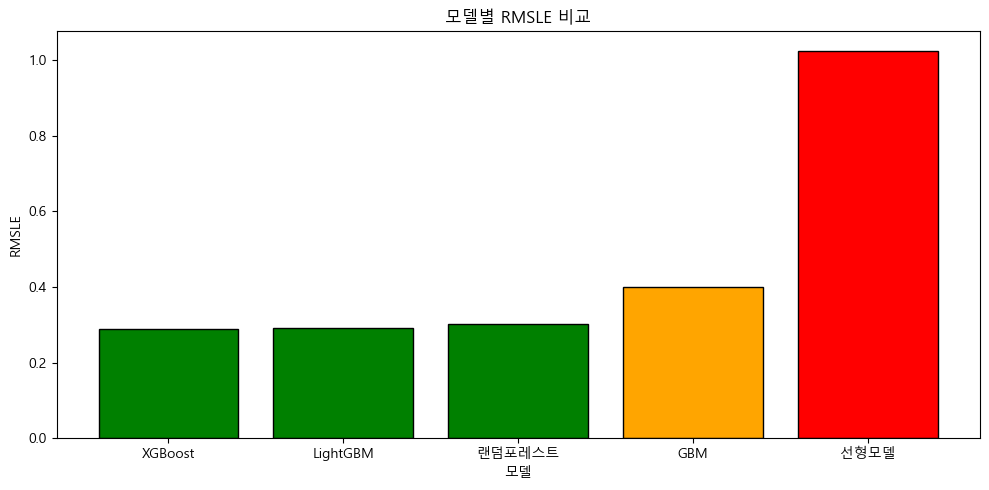

In [11]:
# RMSLE 비교 막대그래프
models = ['XGBoost', 'LightGBM', '랜덤포레스트', 'GBM', '선형모델']
rmsle  = [0.290, 0.293, 0.303, 0.399, 1.024]

plt.figure(figsize=(10, 5))
plt.bar(models, rmsle, color=['green', 'green', 'green', 'orange', 'red'], edgecolor='black')
plt.title('모델별 RMSLE 비교')
plt.xlabel('모델')
plt.ylabel('RMSLE')

plt.tight_layout()
plt.show()